# Progetto Machine Learning Advanced

## Introduzione

### L'obiettivo di questo progetto è sviluppare un modello di Machine Learning capace di prevedere la progressione della malattia del diabete ad un anno di distanza, utilizzando il dataset "Diabetes" di Scikit-Learn. Il dataset comprende 442 pazienti e 10 variabili fisiologiche (età, sesso, BMI, pressione sanguigna e sei misurazioni del siero sanguigno).

In [1]:
# Importo il dataset Diabetes di sckit-learn

import pandas as pd
from sklearn.datasets import load_diabetes

In [2]:
# Carico il dataset

diabetes = load_diabetes()

In [3]:
# Converto i dati in un DataFrame di pandas

df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

In [4]:
# Mostro le prime righe del DataFrame

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


È subito possibile vedere che ogni feature tranne la variabile target è stata precedentemente scalata. Il metodo usato per lo scaling è descritto nella pagina di sklearn dedicata a questo dataset, ed è il risultato della formula: $$\hat{x}_i = \frac{x_i - \bar{x}}{\sigma \sqrt{n}}$$
Questa trasformazione fa si che la somma dei quadrati di ogni feature sia uguale a 1, in altre parole la norma L2 di ogni feature, vista come vettore, è uguale o molto vicina a 1. Oltretutto la media di ogni variabile, tranne la variabile target, è centrata a 0.
Tale scelta di standardizzazione ha alcuni vantaggi immediati, poiché rende i valori delle singole variabili più equi, impedendo la dominanza di alcune feature la cui scala è naturalmente più grande di altre, facilita l'interpretabilità delle singole variabili, e rende omogenea la varianza globale delle feature

Questo spiega anche perché i valori di 'age' e 'sex' non mostrano valori intuitivi o riconoscibili (la colonna sex inoltre mostra il risultato di un proesso di encoding).
Come conseguenza della centratura rispetto alla media e alla normalizzazione, e poiché in questo speifico caso la media per ogni variabile è 0, molti dati hanno valori negativi. Inoltre si può vedere come i valori di 'sex' siano sempre e solo 2, uno per 'male' e uno per 'female'.

Poiché i modelli basati sulla discesa del gradiente, come Regressione Lineare, Ridge o Lasso, sono facilitati da un preprocessing simile, la scelta del modello di ML da testare sul dataset è già inizialmente indirizzata verso uno di essi.

Pur non ritnendo necessario modificare i nomi delle colonne per renderli più comprensibii, inserisco sotto la descrizioe dell'acronimo per ogni variabile:

bmi ----> body mass index

bp  ----> blood pressure (average)

s1  ----> tc, total serrum cholesterol

s2  ----> ldl, low density lipoproteins

s3  ----> hdl, high density lipoproteins

s4  ----> tch, total cholesterol

s5  ----> ltg, possibly log of serum triglycerides level

s6  ----> glu, blood sugar level

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [6]:
# Conto i valori mancanti per sicurezza

df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

L'assenza di valori mancanti ci permetterà di fare previsioni sul set senza dover ricorrere a forme di imputazione, ed è un segnale di qualità del dataset

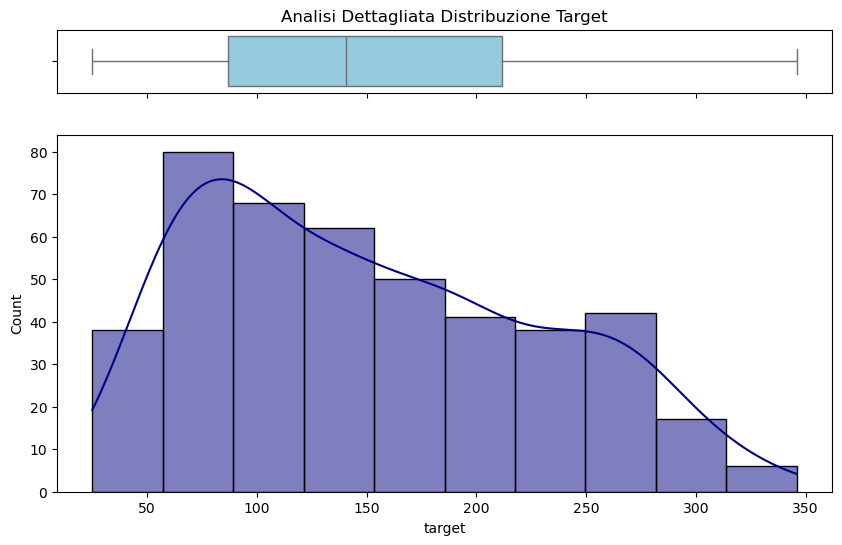

In [7]:
# Analizzo la distribuzione della variabile target

import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10,6))
sns.boxplot(df["target"], ax=ax_box, orient="h", color="skyblue")
sns.histplot(df["target"], kde=True, ax=ax_hist, color="navy")
ax_box.set(title='Analisi Dettagliata Distribuzione Target')
plt.show()

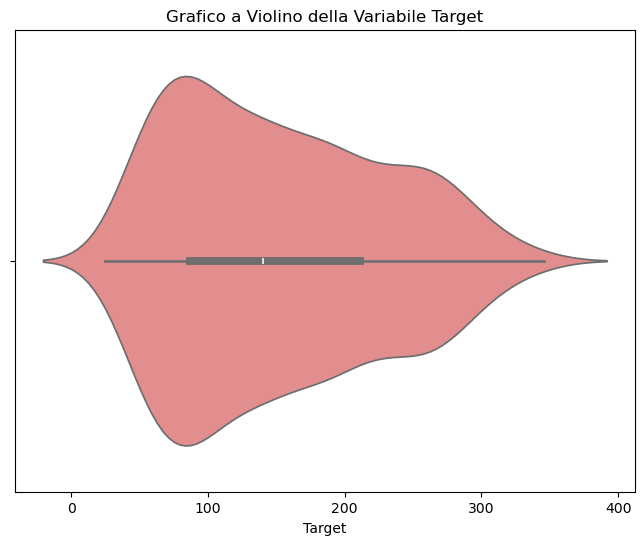

In [8]:
# Visualizzo un grafico a violino per migliorare l'analisi visiva della distribuzione del target

plt.figure(figsize=(8, 6))
sns.violinplot(x=df['target'], color='lightcoral')
plt.title('Grafico a Violino della Variabile Target')
plt.xlabel('Target')
plt.show()

In [9]:
# Calcolo il coefficiente di asimmetria del target

skewness = df['target'].skew()
print(f'Coefficiente di asimmetria del target: {skewness}')

Coefficiente di asimmetria del target: 0.44056293407014124


In [10]:
# Uso il metodo IQR per essere sicuro di identificare possibili outlier

Q1 = df['target'].quantile(0.25)
Q3 = df['target'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['target'] < lower_bound) | (df['target'] > upper_bound)]
outliers_count = outliers.shape[0]
outliers_count

0

In [11]:
desc_target = df['target'].describe()
desc_target 

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

La distribuzione dei valori della variabile target (un misura quantitativa della progressione della malattia ad un anno di distanza) sembra moderatamente sbilanciata a sinistra, tuttavia il coefficiente di asimmetria compreso tra -0.5 e 0.5 non indurrebbe a compiere una trasformazione. Potrebbe essere interessante tuttavai tentare di trasfomrare il target in scala logaritmica e vedere come cambia l'R2.

L'assenza di outlier conferma che la funzione di costo MSE di un modello lineare non sarebbe pesantemente influenzata da valori fuori scala.

Si procede quindi senza modifiche al target. Si tiene comunque presente che un modello come XGBoost potrebbe risultare efficace, essendo immune alla distribuzione asimmetrica.

I valori di Media (152.13) e Deviazione Standard (77.1) ci danno un'idea di accettabilità dei valori di metriche adatte a modelli lineari come il MSE o il MAE.

### Per evitare qualsiasi tipo di data leakage decisionale procedo subito con lo splitting 

In [12]:
# Separo le variabili indipendenti dalla variabile target

X = df[diabetes.feature_names]
y = df['target']

In [13]:
# Procedo con lo splitting

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Poiché le prossime analisi conterrano confronti tra le variabili indipendenti e il target, che potrebbero indirizzare decisioni future, si è deciso di dividere immediatamente il train set dal test set

Poiché il coefficiente di asimmetria calcolato precedentemente mostra valori inferiori a 1, non c'è bisogno di stratificazione del target

## Creazione del Baseline

### Per permettere confronti numerici che giustificheranno la valutazione delle performance dell'algoritmo che verrà scelto e addestrato sul dataset in seguito alle prossime analisi, si è scelto di usare una **Linear Regression** semplice come modello Baseline, vista la sua assenza di regolarizzazione, la natura del dataset, le analisi precedentemente sostenute

### Scelta della Metrica di Valutazione: Mean Squared Error (MSE)

**Perché l'MSE?**
* **Penalizzazione dei valori grandi:** Elevando al quadrato la differenza tra valori predetti ($y_i$) e valori reali ($\hat{y}_i$), l'MSE assegna un peso maggiore agli errori più grandi. Questo è fondamentale nel dataset *diabetes*, dove una previsione molto distante dal valore reale della progressione della malattia è più rischiosa di tanti piccoli errori.

In [14]:
# Creo un modello baseline usando una Regressione Lineare semplice

from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

LinearRegression()

In [15]:
# Valuto il modello sui dati di test

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_baseline_pred = baseline_model.predict(X_test)

baseline_r2 = r2_score(y_test, y_baseline_pred)

print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, y_baseline_pred)):.4f}")
print(f"Baseline R²: {baseline_r2:.4f}")

Baseline RMSE: 53.3696
Baseline R²: 0.4849


È subito possibile notare che il valore del RMSE per il modello di Regressione Lineare semplice (~53.4) mostra che questa strategia contribuisce già in buona parte a migliorare scelte basate unicamente sulla media dei valori del target, visto il valore più basso rispetto alla deviazione standard del dataset di partenza

Il valore di R2 per adesso non fornisce informazioni rilevanti (pur essendo moderatamente basso), ma verrà confrontato in seguito con quello rilevato sul modello finale

### Si procede a questo punto con analisi più specifiche sulla relazione tra le variabili indipendenti e il target per cercare di individuare un modello più efficace

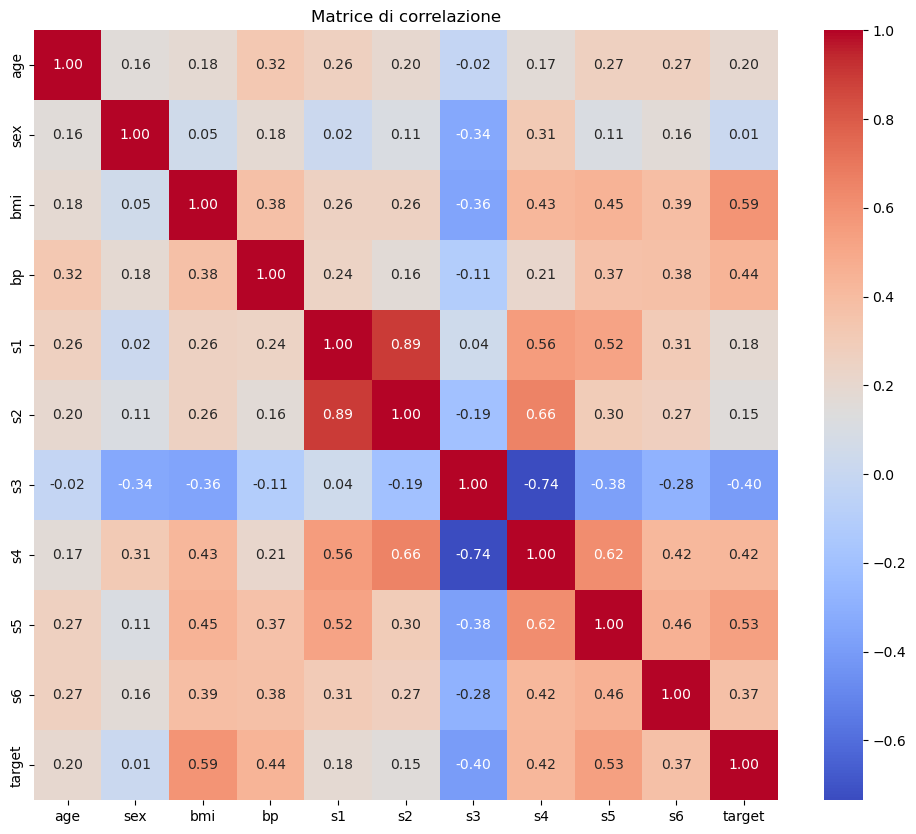

In [16]:
# Visualizzo una heatmap delle correlazioni tra le variabili
# Per farlo, concateno X_train e y_train in un unico DataFrame

train_df = pd.concat([X_train, y_train], axis=1)

plt.figure(figsize=(12, 10))
correlation_matrix = train_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice di correlazione')
plt.show()

Si possono facilmente notare due correlazioni molto forti: tra i predittori s2 e s1 c'è una fortissima correlazione positiva (0.89), mentre tra s4 e s3 c'è una forte correlazione negativa (-0.74). 
In entrambi i casi queste relazioni potrebbero indurre un'alta varaianza ad un modello che non ne tiene conto, e rendere i coefficienti molto instabili. Siamo di fronte ad un caso di **multicollinearità**.

Di fronte a casi come questo potrebbe essere consigliabile indirizzarsi verso modelli che prevedono regolarizzazione, come Ridge o Lasso.

È possibile inoltre già notare una correlazione moderatamente positiva tra la variabile target e i predittori bmi e s5

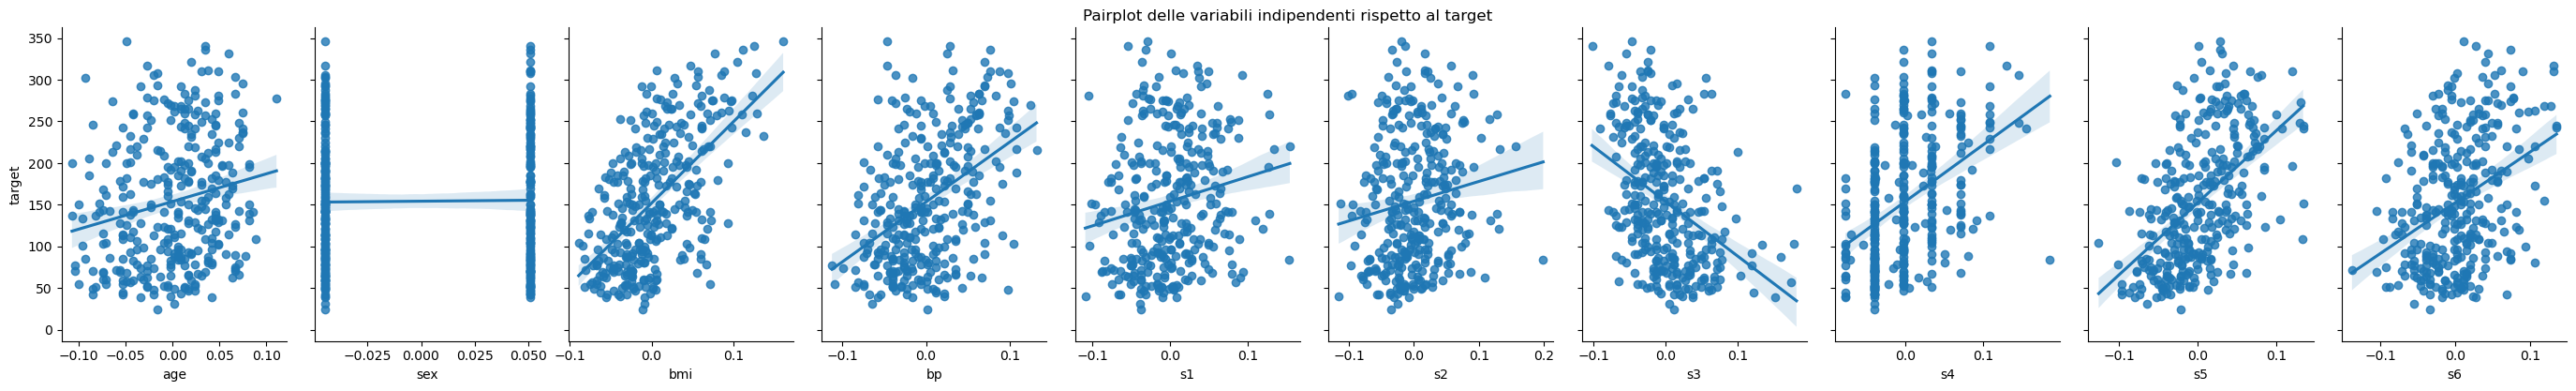

In [17]:
# Analizzo la linearità tra le variabili indipendenti e la variabile target
# Creo un pairplot delle variabili indipendenti rispetto al target

sns.pairplot(train_df, x_vars=diabetes.feature_names, y_vars='target', height=4, aspect=0.7, kind='reg')
plt.suptitle('Pairplot delle variabili indipendenti rispetto al target', y=1.02)
plt.show()

La visualizzazione delle dispersione tra predittori e target mostra che la maggior parte delle variabili indipendenti possono soddisfare i parametri di un modello regolarizzato. 
Tuttavia il comportamento della varibile s4 ha una natura diversa (La variabile sex ha una forma a due gradini perché codifica di una varibile booleana). Da un lato, nonostante l'andamento a gradini verticali, il trend crescente di ciascun gradino potrebbe suggerire che un modello regolarizzato come Lasso avrebbe effetto, nel caso in cui la variabile sia irrilevante.

Come si evince dalla heatmap delle correlazioni, se la variabile sex ha quasi nessuna correlazione con il target ed è più immediato considerarla irrilevante, l'alta correlazione negativa tra s4 e s3 può indurre a credere che l'eliminazione di s4 sarebbe una naturale scelta di un algoritmo basato sulla distanza L1, come Lasso.

Per avere maggiore sicurezza, in fase di addestramento del modello, si potrebbe testare l'algoritmo una prima volta sul dataset di partenza, e successivamente mescolando in modo casuale l'ordine dei dati della variabile s4 per controllare i valori di R2 prima e dopo. Se i valori non calano dopo la permutazione, è un ulteriore forte segnale di irrilevanza statistica del predittore.

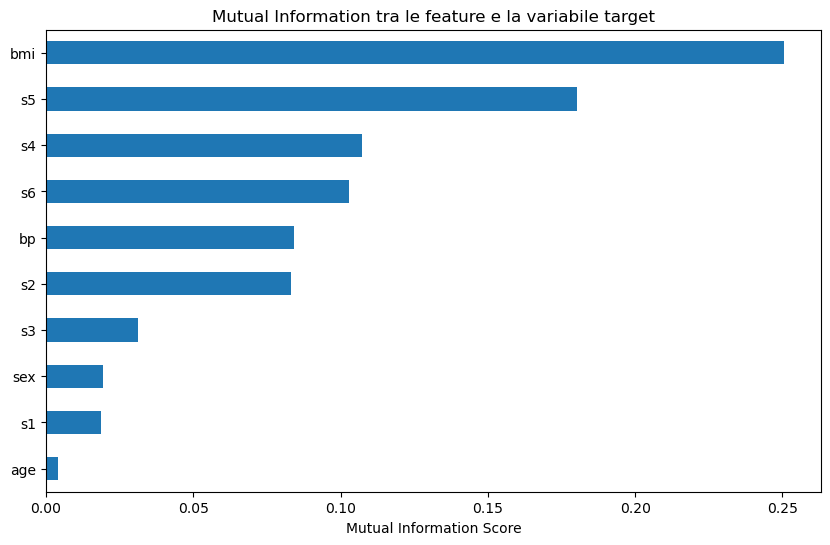

age    0.003959
s1     0.018515
sex    0.019442
s3     0.031319
s2     0.083203
bp     0.084300
s6     0.102987
s4     0.107297
s5     0.180098
bmi    0.250542
dtype: float64

In [18]:
# Faccio un'analisi della Mutual Information tra le variabili per cercare di capire l'importanza delle varie feature

from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_train, y_train)
mi_scores = pd.Series(mi_scores, index=X_train.columns).sort_values()
plt.figure(figsize=(10, 6))
mi_scores.plot(kind='barh')
plt.title('Mutual Information tra le feature e la variabile target')
plt.xlabel('Mutual Information Score')
plt.show()
mi_scores

Poiché il test di MI mostra un valore mediamente alto per il predittore s4, sollevando dubbi sull'efficenza di un suo scarto da parte di Lasso, si ritiene giusto procedere con un'analisi visiva di eventuali pattern non-lineari tra alcune delle feature , e con il calcolo del **Variance Inflation Factor (VIF)**.

Per la visualizzazione sono state incluse le variabili con i valori più alti di **Mutual Information**, ovvero bmi (0.248) e s5 (0.179), che rappresentano i motori principali della varianza del target. Nonostante una MI più contenuta, s1 e s3 sono state selezionate per identificare visivamente eventuali collinearità che i coefficienti lineari potrebbero sottostimare. L'inclusione di bp e s6 completa il quadro clinico, coprendo le dimensioni che mostrano una dipendenza statistica significativa (MI > 0.07)

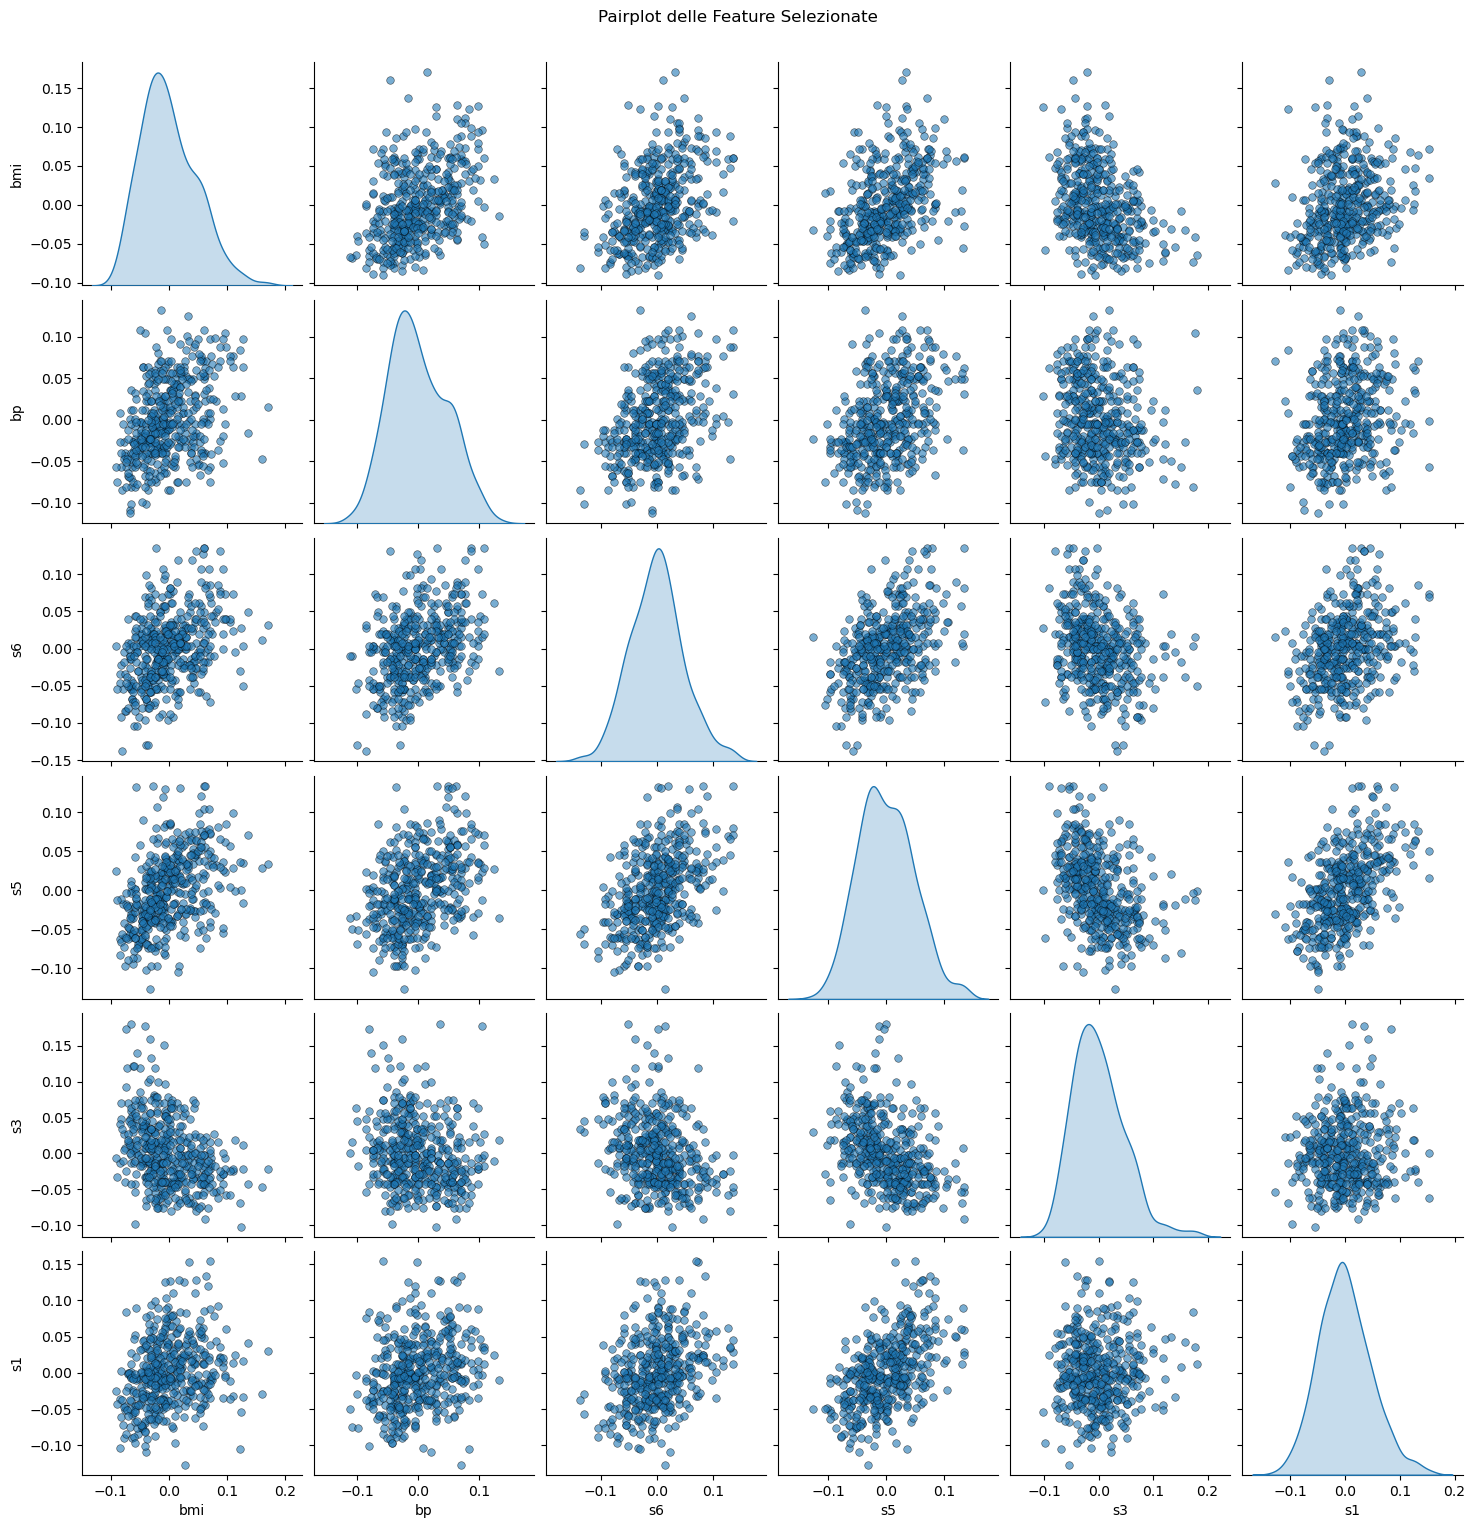

In [19]:
# Visualizzo un pairplot tra alcune variabili scelte, per individuare eventuali patterns o relazioni non lineari

features_interessanti = ['bmi', 'bp', 's6', 's5', 's3', 's1']

sns.pairplot(df[features_interessanti], diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})
plt.suptitle('Pairplot delle Feature Selezionate', y=1.02)
plt.show()

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train.copy()
X_vif['intercept'] = 1 # Il VIF ha bisogno di una costante

vif_df = pd.DataFrame()
vif_df['Feature'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# Escludo la colonna intercept dal VIF
vif_df = vif_df[vif_df['Feature'] != 'intercept']
vif_df.sort_values('VIF', ascending=False)
vif_df

,Feature,VIF
0,age,1.215731
1,sex,1.247843
2,bmi,1.528381
3,bp,1.418460
4,s1,54.296638
5,s2,35.595506
6,s3,13.836183
7,s4,9.317236
8,s5,9.800525
9,s6,1.461173


In seguito ad analisi più approfondite sulla rilevanza delle feature, è possibile affermare che il modello Lasso paventato prima rischierebbe di escludere predittori la cui rilevanza potrebbe essere fondamentale per alcune previsioni. Inoltre il numero limitato di variabili indipendenti disincentiva la strategia dell'eliminazione di alcune di esse, processo che il Lasso molto probabilmente metterebbe in moto, vista la multicollinearità evidente.

L'analisi visiva dell'interazione tra alcune feature non mostra segni evidenti di relazioni o pattern non lineari, che potrebbero favorire modelli più adatti a gestire raggruppamenti meno intuitivi. Inoltre, come già rilevato nel precedente commento, il numero delle feature disincentiva il ricorso a tecniche avanzate di gestione della dimensionalità come la PCA, che potrebbe anche portare a una perdita di informazioni su questo dataset

A questo punto si devia la scelta verso un modello Ridge, la cui regolarizzazione non rischia di azzerare i coefficienti di alcune variabili pur rimanendo un modello lineare. 
Si tiene ancora in considerazione che un modello ensemble come XGBoost potrebbe risultare un'ottima scelta, ma si decide in questo caso di favorire il Ridge viste le modeste dimensioni del dataset, che potrebbero essere fuorvianti per un modello potente come XGBoost

Sarebbe inoltre interessante vedere il comportamento di un algoritmo 'via di mezzo' tra Ridge e Lasso come l'Elastic Net, che non azzererebbe le variabili correlate pur essendo un modello lineare regolarizzato

## Addestramento e Validazione del Ridge

Avendo a che fare con un dataset piccolo (442 entrate) il rischio maggiore è quello di incorrere in overfitting, quindi valuteremo attentamente i valori del parametro alpha (lambda in letteratura), responsabile della penalizzazione dei coefficienti del modello, testando alcuni valori standard e altri valori aggiuntivi in scala logaritmica 

Nonostante i dati di Diabetes siano già preprocessati, li scaleremo ulteriormente all'interno di una Pipeline per evitare data leakage. 

Considerando nuovamente le dimensioni del dataset, verrà preferita una strategia di cross-validation basata su RepeatedKFold, per aumentare l'affidabilità dei risultati

In [21]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Definisco la pipeline includendo lo standard scaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

In [22]:
# Definisco i parametri di alpha 

alphas_standard = [0.1, 1.0, 10.0, 100.0]
alphas_log = np.logspace(-3, 5, 50).tolist()
all_alphas = alphas_standard + alphas_log

param_grid = {
    'ridge__alpha': all_alphas
}

In [23]:
# Configuro la cross-validation

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=42)

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

In [24]:
# Eseguo la grid search

grid_search.fit(X_train, y_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=42),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'ridge__alpha': [0.1, 1.0, 10.0, 100.0, 0.001,
                                          0.0014563484775012444,
                                          0.0021209508879201904,
                                          0.0030888435964774815,
                                          0.004498432668969444,
                                          0.006551285568595509,
                                          0.009540954763499945,
                                          0.01389495494...
                                          0.029470517025518096,
                                          0.04291934260128776,
                                          0.0625055192527397,
                                          0.09102981779915217,
                                          0.13257113655901082,
                                          0.19306977288832497,
                                          0.2811768697974228,
                                          0.4094915062380423,
                                          0.5963623316594643, 0.868511373751352,
                                          1.2648552168552958,
                                          1.8420699693267144,
                                          2.6826957952797246, 3.906939937054613,
                                          5.689866029018293, 8.286427728546842,
                                          12.067926406393289, ...]},
             scoring='neg_mean_squared_error')

In [25]:
# Risultati della grid search

print(f"Miglior Alpha trovato: {grid_search.best_params_['ridge__alpha']:.4f}")
print(f"Miglior MSE in CV: {-grid_search.best_score_:.4f}")

Miglior Alpha trovato: 25.5955
Miglior MSE in CV: 3118.9336


In [26]:
# Vedo se il migliore alpha appartiene al set standard o log

if grid_search.best_params_['ridge__alpha'] in alphas_standard:
    print("Il valore ottimale era tra quelli standard.")
else:
    print("Il valore ottimale è stato trovato grazie alla scala logaritmica.")

Il valore ottimale è stato trovato grazie alla scala logaritmica.


In [27]:
# Ricavo la radice del mse per una valutazione 'in scala' dell'errore del modello

rmse = np.sqrt(-grid_search.best_score_)
print(f"Miglior RMSE in CV: {rmse:.4f}")

Miglior RMSE in CV: 55.8474


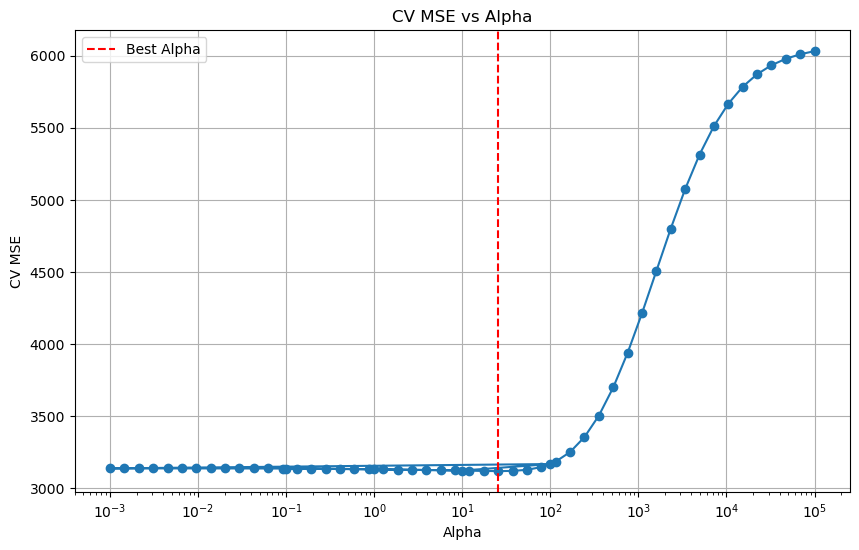

In [28]:
# Visualizzo l'andamento della CV score rispetto ad alpha

results = pd.DataFrame(grid_search.cv_results_)
results['alpha'] = results['param_ridge__alpha'].astype(float)

plt.figure(figsize=(10, 6))
plt.semilogx(results['alpha'], -results['mean_test_score'], marker='o')
plt.axvline(x=grid_search.best_params_['ridge__alpha'], color='red', linestyle='--', label='Best Alpha')
plt.title('CV MSE vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('CV MSE')
plt.legend()
plt.xscale('log')
plt.grid()
plt.show()

Come mostrato dal grafico, per valori di $\alpha < 10^1$ l'errore rimane piatto e basso, suggerendo che in questa fase il modello si comporta quasi come una regressione lineare standard. Diversamente per valori di $\alpha > 10^2$ l'errore impenna drasticamente: qui la penalità è troppo forte e il modello diventa troppo semplice (underfitting) e schiaccia i coefficienti verso lo zero, perdendo capacità predittiva.

Scegliere l'Alpha indicato dalla linea rossa significa accettare un piccolissimo aumento di errore teorico pur di ottenere un modello i cui pesi (es. l'importanza del BMI) non cambino drasticamente se cambiamo leggermente i pazienti del campione.

Prima di valutare il modello sul test set pulito, si effettua ancora un'analisi finale: l'analisi dei coefficienti per valutare la coerenza con le analisi precedentemente effettuate

/var/folders/qw/5923zhqn0l5b3_z7mmqhfs_w0000gn/T/ipykernel_50933/3560268604.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


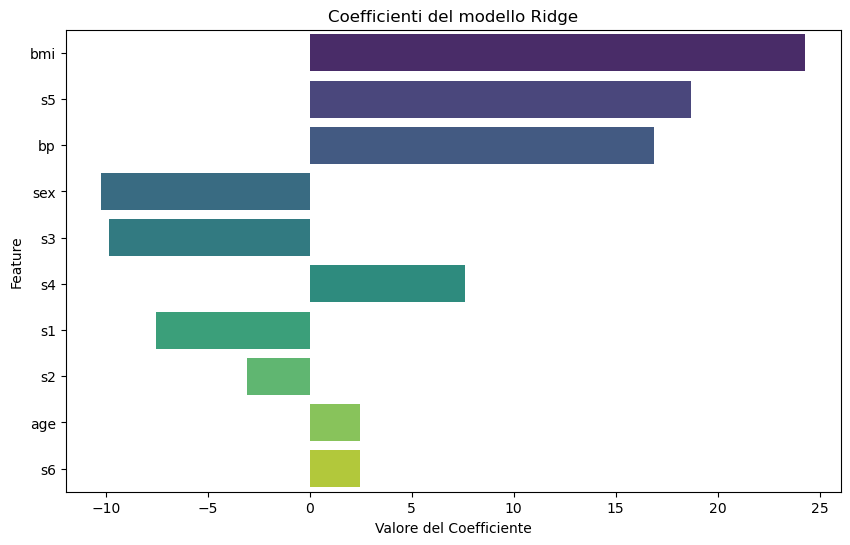

In [29]:
# Ispeziono i coefficienti

coefs = grid_search.best_estimator_.named_steps['ridge'].coef_
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefs})
coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Coefficienti del modello Ridge')
plt.xlabel('Valore del Coefficiente')
plt.ylabel('Feature')
plt.show()

Il confronto tra la griglia dei coefficienti assegnati dal Ridge e i valori della Mutual Information e del VIF racconta molto sull'efficenza della scelta di questo modello regolarizzato. 
In particolare, è immediato notare la coerenza tra i risultati ottenuti in MI e VIF dei predittori **bmi** e **bp** e i pesi a loro assegnati in fase di addestramento. Tali risultati, uniti a quelli visti sulla heatmap delle correlazioni, ci rassicurano nell'affermare che la body mass index è un buon predittore lineare dell'andamento del diabete in un paziente

Curioso il caso di **s5**, a cui è assegnato un coefficiente alto, in linea con correlazione col target e MI. Tuttavia il valore del VIF piuttosto alto (~10), se messo in relazione con la correlazione tra questo predittore ed altri (come con s4, la cui correlazione di 0.64 non è trascurabile), può comunicare che la scelta del peso assegnatogli potrebbe essere non del tutto lucida, bensì il risultato delle interazioni lineari e non con le altri variabili

I **limiti** dell'algoritmo utilizzato dal Ridge per penalizzare i coefficienti è ampiamente visibile osservando il valore del coefficiente per s6, il più basso con questo addestramento.
Infatti, i valori mostrati da questo predittore in MI (piuttosto alto) e in VIF (basso) lascerebbero pensare che le informazioni contenute in questa feature siano rilevanti per una corretta predizione, e quindi in controtendenza con il basso utilizzo che ne fa l'algoritmo.
Probabilmente, poiché la rete di correlazioni tra le variabili indipendenti è piuttosto complessa, il processo di aumento del bias messo in moto dal Ridge ha penalizzato un indicatore che invece potrebbe risultare vitale

Pur riconoscendo i limiti di questo modello (senza feature engineering più sofisticato) su questo dataset, i valori del RMSE giustificano comunque una valutazione sui dati di test puliti

In [30]:
# Procedo con la valutazione sul test set

y_test_pred = grid_search.best_estimator_.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
print(f"MSE sul Test Set: {test_mse:.4f}")
print(f"RMSE sul Test Set: {test_rmse:.4f}")

MSE sul Test Set: 2818.7066
RMSE sul Test Set: 53.0915


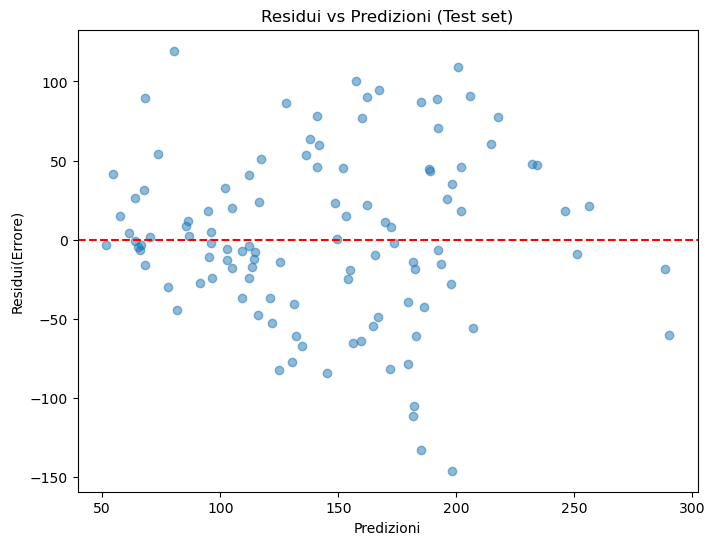

In [31]:
# Confronto i residui con le predizioni

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, y_test - y_test_pred, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residui vs Predizioni (Test set)')
plt.xlabel('Predizioni')
plt.ylabel('Residui(Errore)')
plt.show()

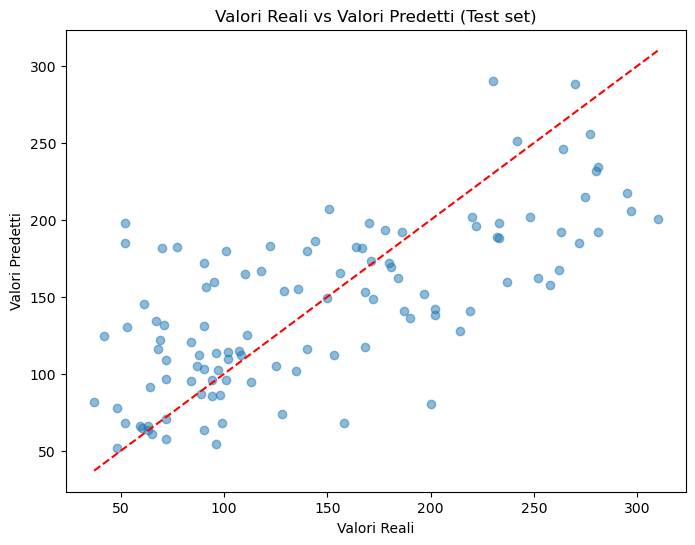

In [32]:
# Confronto tra valori reali e predetti

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Valori Reali vs Valori Predetti (Test set)')
plt.xlabel('Valori Reali')
plt.ylabel('Valori Predetti')
plt.show()

In [33]:
# Eseguo il test di Breusch-Pagan per verificare l'eteroschedasticità dei residui

from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

residuals = y_test - y_test_pred

# Aggiungo una costante per il test di Breusch-Pagan
X_test_const = sm.add_constant(X_test)
_, pval, _, _ = het_breuschpagan(residuals, X_test_const) # Il test di Breusch-Pagan restituisce 4 valori, ma ci interessa solo il p-value

print(f"P-value del test di Breusch-Pagan: {pval:.4f}")
if pval < 0.05:
    print("Esiste evidenza di eteroschedasticità (varianza dei residui non costante).")
else:
    print("I residui sembrano essere omoschedastici (varianza costante).")

P-value del test di Breusch-Pagan: 0.0310
Esiste evidenza di eteroschedasticità (varianza dei residui non costante).


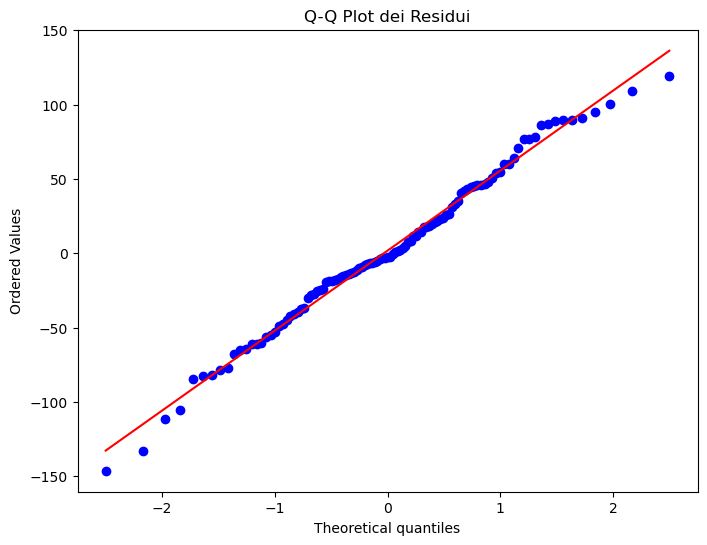

In [34]:
# Creo un Q-Q plot per verificare la normalità dei residui

import scipy.stats as stats

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot dei Residui')
plt.show()

In [35]:
# Ricavo la media dei residui per verificare se ci sono bias sistematici

residuals_mean = np.mean(residuals)
print(f"Media dei residui: {residuals_mean:.4f}")

Media dei residui: 1.8042


Il grafico  dei **Q-Q plot** mostra una distribuzione dei residui approssimativamente normale per i quantili centrali, ma evidenzia scostamenti nelle code. Ciò suggerisce che il modello lineare fatica a catturare la variabilità dei pazienti con progressione della malattia molto bassa o molto elevata.

Il test di **Breusch-Pagan (p-value = 0.0310)** rigetta l'ipotesi di omoschedasticità. La varianza dei residui non è costante, confermando visivamente l'effetto "a imbuto" osservato nei residui; l'affidabilità delle previsioni tende quindi a diminuire per certi range dei parametri fisiologici.

La media dei residui (1.80) conferma l'assenza di un bias sistematico rilevante a livello globale, sebbene indichi una marginale sottostima sistematica che non inficia l'uso del modello come strumento di screening preliminare.

In un contesto medico, questi risultati dicono che il modello Ridge predice bene il paziente "medio", ma è statisticamente conscio di faticare con i quadri clinici più complessi o estremi.

Le prestazioni del modello Ridge sui dati del test set puliti mostrano un leggero miglioramento rispetto alla validazione (~53 contro ~56), fornendo un feedback speranzoso sulle scelte effettuate. Tuttavia, un piccolo miglioramento dell'errore quadratico può essere anche un segno di overfitting sul dataset, il che ci spinge a tenere in considerazione approfondimenti successivi per escludere questa possibilità.

In [36]:
# Confronto il valore di r2 durante il training con quello dopo il test, e aggiungo anche il r2 del modello baseline per avere un confronto più completo

y_train_pred = grid_search.best_estimator_.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

r2_test = r2_score(y_test, y_test_pred)

print(f"R² sul Training Set: {r2_train:.4f}")
print(f"R² sul Test Set: {r2_test:.4f}")
print(f"R² del modello baseline sul Test Set: {baseline_r2:.4f}")

R² sul Training Set: 0.5138
R² sul Test Set: 0.4903
R² del modello baseline sul Test Set: 0.4849


In [37]:
# Calcolo il MAE e lo confronto con RMSE

from sklearn.metrics import mean_absolute_error

test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"MAE sul Test Set: {test_mae:.4f}")
print(f"RMSE sul Test Set: {test_rmse:.4f}")

MAE sul Test Set: 41.4924
RMSE sul Test Set: 53.0915


In [38]:
# Visualizzo il range dei valori del target per capire meglio la scala degli errori

print(f"Range del target: {y.max() - y.min():.4f}")

# Calcolo le percentuali di errore (MAE) rispetto al range del target e alla media

percent_error_range = (test_mae / (y.max() - y.min())) * 100
percent_error_mean = (test_mae / y.mean()) * 100

print(f"Percentuale di errore (MAE) rispetto al range del target: {percent_error_range:.2f}%")
print(f"Percentuale di errore (MAE) rispetto alla media del target: {percent_error_mean:.2f}%")

Range del target: 321.0000
Percentuale di errore (MAE) rispetto al range del target: 12.93%
Percentuale di errore (MAE) rispetto alla media del target: 27.27%


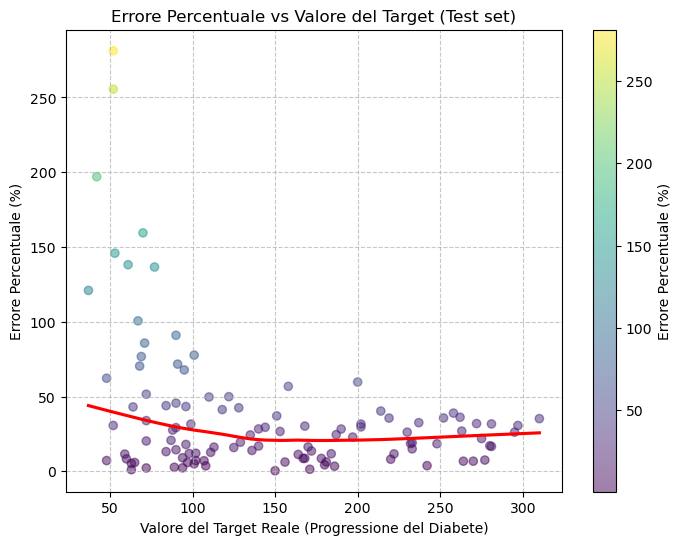

MAPE sul Test Set: 37.16%


In [39]:
# Visualizzo un grafico che mostra l'errore percentuale rispetto al valore del target

plt.figure(figsize=(8, 6))
percent_errors = np.abs(y_test - y_test_pred) / y_test * 100 

# Scatter con colore basato sull'entita dell'errore percentuale
scatter = plt.scatter(y_test, percent_errors, c=percent_errors, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Errore Percentuale (%)') 

# Aggiungo una linea di tendenza per vedere se l'errore cresce/decresce con il target
sns.regplot(x=y_test, y=percent_errors, scatter=False, color='red', lowess=True)

plt.title('Errore Percentuale vs Valore del Target (Test set)')
plt.xlabel('Valore del Target Reale (Progressione del Diabete)')
plt.ylabel('Errore Percentuale (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Calcolo l'errore percentuale medio (MAPE)

mape = np.mean(percent_errors)
print(f"MAPE sul Test Set: {mape:.2f}%")

Questi ultimi confronti ci danno un'impressione estrema della scelta fatta.

Il valore di **R2** su training set e test set è quasi lo stesso (~51 contro ~49), il che ci dice che attraverso il tuning pesante del parametro alpha, la generalizzazione del Ridge funziona piuttosto bene, e che il richio di overfitting sembra scongiurato.

Un **MAE** di ~41.5 punti (sostanzialmente più basso rispetto al RMSE, prova ulteriore che il modello penalizza valori estremi del target), sebbene possa sembrare elevato, rappresenta solo il 12.93% dell'intero spettro di progressione della malattia (range 321). Ciò indica che il modello è in grado di collocare correttamente un paziente nella macro-categoria di rischio (basso, medio, alto) con una discreta sicurezza.

l grafico dell'errore percentuale rivela che la precisione del modello aumenta proporzionalmente alla gravità della progressione: per target $< 100$, vediamo diversi punti con errori superiori al 100-200%. Questo accade perché, matematicamente, anche un piccolo errore assoluto (es. sbagliare di 30 punti su un valore reale di 40) esplode in termini percentuali. Mentre per valori bassi del target l'incertezza relativa è elevata, per pazienti con progressione superiore a 150 l'errore si stabilizza, rendendo il modello un supporto decisionale più affidabile proprio nei casi clinici più critici.

Rispetto alla media del target, l'errore medio si attesta al 27.27%. Sebbene questa variabilità impedisca l'uso del modello come strumento diagnostico assoluto, il guadagno informativo rispetto a una baseline ingenua giustifica il suo impiego come sistema di screening per identificare precocemente i pazienti che necessitano di interventi terapeutici più aggressivi.

### **Limiti della ricerca**

L'analisi dati e la modellizzazione di un algoritmo di Machine Learning mostrate nel notebook rappresentano una possibile strategia con cui affrontare questo particolare dataset. Pur rappresentando un percorso tecnicamente corretto e potenzialmente efficace, presenta una serie di limiti strutturali e procedurali di cui tenere conto.  

Il dataset di partenza, facendo parte di un gruppo di dataset 'toy' di scikit-learn, è intrinsecamente poco rappresentativo della realtà del raccoglimento e conservazione dei dati di ambito medico, sia perché i campioni presi in considerazione sono pochi per essere significativi e per permettere ad un algoritmo di ritenersi 'adatto' alla tipologia di problema, sia perché le scelte di preprocessing effettuate a priori indirizzano già verso una strategia precisa, e perché riducono le scelte iniziali.
Inoltre, l'ambito della ricerca - quello medico - è noto per il rumore dei dati, per la sporcizia delle rilevazioni e per la complessità degli indicatori forniti, che subiscono spesso variazioni e non sono univoci, rendendo più difficile catturare l'equilibrio tra linearità e non linearità delle variabili.

Durante il progetto si è ritenuto necessario per garantire semplicità, pur non deviando dalla task, limitare il numero di scelte possibili ad un solo algoritmo da addestrare. Sebbene l'analisi esplorativa e quelle successive abbiano indirizzato la scelta verso un modello Ridge, l'iperparametro di regolarizzazione migliore trovato in cross-validation (~26) indica chiaramente che le relazioni tra le variabili, e tra le variabili e il target, sono forse troppo complesse per essere catturate da un modello lineare.

Nondimeno, il processo decisionale manca totalmente di feature engeenering, che avrebbe potuto diminuire di qualche punto la varianza dell'algoritmo (a.e. tramite la trasformazione della variabile bim in bim^2).

Infine, non è stata trascurata l'idea che un algoritmo che prevede tecniche di ensemble come Random Forest o XGBoost potesse restituire risultati migliori. Tuttavia, la conferma del modello Ridge è stata valutata proprio a causa della piccola dimensione del dataset di partenza, che avrebbe potuto confondere modelli più complessi come quelli menzionati.

## **Conclusioni Finali**

* **Validazione del Percorso Metodologico tramite Baseline**: L'introduzione di un modello di Linear Regression standard come baseline ha permesso di quantificare l'efficacia delle scelte effettuate. Il confronto numerico mostra che il modello Ridge ottimizzato supera il baseline (RMSE: 53.09 vs 53.37; $R^2$: 0.490 vs 0.485). Sebbene lo scarto numerico sembri contenuto, esso rappresenta un punto di equilibrio ottimale tra errore e stabilità dei coefficienti.

* **Efficacia della Regolarizzazione contro la Multicollinearità**: L'analisi del VIF (Variance Inflation Factor) ha rivelato criticità elevate (VIF > 50 per s1 e s2). L'individuazione di un valore di $\alpha$ elevato (~25.6) tramite Grid Search conferma che il modello ha dovuto applicare una forte penalizzazione $L2$ per stabilizzare i coefficienti, risolvendo le instabilità strutturali rilevate nel baseline e garantendo che nessun predittore ridondante dominasse erroneamente la previsione.

* **Stabilità e Generalizzazione**: Il modello dimostra un'eccellente capacità di generalizzazione, evidenziata dal ridotto scostamento (circa il 2%) tra l' $R^2$ di training (0.51) e quello di test (0.49). Questo equilibrio conferma che il tuning degli iperparametri e la strategia di Repeated K-Fold Cross-Validation hanno efficacemente scongiurato il rischio di overfitting, tipico di dataset di piccole dimensioni (n=442).

* **Analisi Diagnostica dei Residui ed Eteroschedasticità**: Il test di Breusch-Pagan (p-value = 0.0310) ha formalmente rigettato l'ipotesi di omoschedasticità. La varianza dei residui non è costante, indicando che l'affidabilità del modello varia al variare dei parametri fisiologici. Inoltre, il Q-Q Plot ha evidenziato scostamenti nelle code, segnalando che la struttura lineare fatica a catturare i quadri clinici più estremi o rari.

* **Precisione Relativa e Valutazione del MAE**: Il MAE di 41.49 rappresenta circa il 12.93% del range totale del target. Un dato fondamentale emerso dall'analisi dell'errore percentuale è che la precisione del modello aumenta proporzionalmente alla gravità della progressione (Target > 150), rendendolo un supporto decisionale più affidabile proprio per i pazienti in condizioni cliniche più critiche, dove l'errore relativo si stabilizza.

* **Interpretazione Clinica dei Predittori**: I risultati riflettono le analisi di Mutual Information: il BMI e la variabile s5 emergono come i driver principali. Tuttavia, la penalizzazione subita da s6 (nonostante una MI rilevante) suggerisce che la regolarizzazione Ridge potrebbe aver sacrificato parte del segnale specifico di alcune feature per garantire la coesione del modello globale in un contesto di alta multicollinearità.

* **Sintesi Finale e Limiti**: Il progetto dimostra che un approccio basato sulla diagnosi statistica preventiva (VIF, MI) permette di giustificare ogni scelta algoritmica. Rimangono margini di miglioramento legati alla natura "toy" del dataset e all'assenza di feature engineering (es. termini quadratici). Nonostante questi limiti, il modello Ridge si posiziona come uno strumento di screening efficace, capace di collocare correttamente i pazienti nelle macro-categorie di rischio con una discreta sicurezza.